In [37]:
from gensim.models import Word2Vec

In [38]:
kalimat = [
    ["pemerintah", "menaikkan", "harga", "saham", "pasar", "keuangan"],
    ["investor", "membeli", "saham", "perusahaan", "teknologi", "pasar"],
    ["atlet", "meraih", "medali", "emas", "dalam", "kompetisi", "olahraga"]
]

In [39]:
# 2. Atur parameter yang ingin Anda uji coba
n_vector = 10     # Dimensi vektor (bebas diganti, misal: 5, 10, 50, 100)
window_size = 5   # Ukuran window konteks (bebas diganti, misal: 1, 2, 3)

In [40]:
# 3. Membuat dan melatih model Skip-gram (sg=1)
model_skipgram = Word2Vec(
    sentences=kalimat,
    vector_size=n_vector,
    window=window_size,
    sg=1,          # sg=1 untuk Skip-gram (sg=0 untuk CBOW)
    min_count=1,   # min_count=1 agar semua kata ikut dihitung
    workers=1,
    seed=42
)

In [41]:
def ekstrak_kombinasi_skipgram(kalimat_list, window_size):
    pasangan_kombinasi = []
    
    for kalimat in kalimat_list:
        panjang_kalimat = len(kalimat)
        for i, kata_target in enumerate(kalimat):
            # Tentukan jangkauan jendela di kiri dan kanan
            awal = max(0, i - window_size)
            akhir = min(panjang_kalimat, i + window_size + 1)
            
            for j in range(awal, akhir):
                if i != j:  # Abaikan jika indeksnya sama dengan kata target
                    kata_konteks = kalimat[j]
                    pasangan_kombinasi.append((kata_target, kata_konteks))
                    
    return pasangan_kombinasi

In [42]:
# 1. Ekstrak seluruh pasangan berdasarkan window_size
semua_pasangan = ekstrak_kombinasi_skipgram(kalimat, window_size=window_size)

# 2. Ambil hanya kombinasi pasangan yang UNIK (menghilangkan duplikat)
kombinasi_unik = sorted(list(set(semua_pasangan)))

# 3. Tampilkan Hasil
print(f"=== IDENTIFIKASI KOMBINASI KATA (window={window_size}) ===")
print(f"Total pasangan terbentuk     : {len(semua_pasangan)}")
print(f"Total pasangan KATA UNIK     : {len(kombinasi_unik)}\n")

print("Daftar Kombinasi Kata Unik (Target -> Konteks):")
for target, konteks in kombinasi_unik:
    print(f"Target: '{target}'  -->  Konteks: '{konteks}'")

=== IDENTIFIKASI KOMBINASI KATA (window=5) ===
Total pasangan terbentuk     : 100
Total pasangan KATA UNIK     : 98

Daftar Kombinasi Kata Unik (Target -> Konteks):
Target: 'atlet'  -->  Konteks: 'dalam'
Target: 'atlet'  -->  Konteks: 'emas'
Target: 'atlet'  -->  Konteks: 'kompetisi'
Target: 'atlet'  -->  Konteks: 'medali'
Target: 'atlet'  -->  Konteks: 'meraih'
Target: 'dalam'  -->  Konteks: 'atlet'
Target: 'dalam'  -->  Konteks: 'emas'
Target: 'dalam'  -->  Konteks: 'kompetisi'
Target: 'dalam'  -->  Konteks: 'medali'
Target: 'dalam'  -->  Konteks: 'meraih'
Target: 'dalam'  -->  Konteks: 'olahraga'
Target: 'emas'  -->  Konteks: 'atlet'
Target: 'emas'  -->  Konteks: 'dalam'
Target: 'emas'  -->  Konteks: 'kompetisi'
Target: 'emas'  -->  Konteks: 'medali'
Target: 'emas'  -->  Konteks: 'meraih'
Target: 'emas'  -->  Konteks: 'olahraga'
Target: 'harga'  -->  Konteks: 'keuangan'
Target: 'harga'  -->  Konteks: 'menaikkan'
Target: 'harga'  -->  Konteks: 'pasar'
Target: 'harga'  -->  Konteks: '

In [43]:
# 4. Menampilkan hasil vektor angka untuk kata "saham"
kata_uji = "saham"
vektor_kata = model_skipgram.wv[kata_uji]

In [44]:
print(f"=== HASIL SKIIP-GRAM (n={n_vector}, window={window_size}) ===")
print(f"Ukuran dimensi vektor '{kata_uji}': {vektor_kata.shape[0]}")
print(f"Vektor angka untuk kata '{kata_uji}':\n{vektor_kata}\n")

=== HASIL SKIIP-GRAM (n=10, window=5) ===
Ukuran dimensi vektor 'saham': 10
Vektor angka untuk kata 'saham':
[ 0.00530819  0.09512772  0.04711951  0.05224992  0.04349924  0.05722775
  0.00266594 -0.07442413  0.06794856 -0.00990942]



In [45]:
# 5. Menampilkan daftar seluruh kosakata yang berhasil dipelajari model
print("Daftar kata unik dalam vocabulary:")
print(list(model_skipgram.wv.index_to_key))

Daftar kata unik dalam vocabulary:
['pasar', 'saham', 'olahraga', 'kompetisi', 'dalam', 'emas', 'medali', 'meraih', 'atlet', 'teknologi', 'perusahaan', 'membeli', 'investor', 'keuangan', 'harga', 'menaikkan', 'pemerintah']


# **Algoritma Word2Vec : Skip-Gram**

## Data Understanding

In [68]:
import pandas as pd
import re

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from tqdm import tqdm
import logging

from gensim.models import Word2Vec
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [47]:
def visualisasi_wordcloud(teks_series):
    # Mengambil daftar stopword bahasa Indonesia dari Sastrawi
    factory = StopWordRemoverFactory()
    stopword_indo = set(factory.get_stop_words())
    
    # Menggabungkan seluruh baris teks menjadi satu string teks panjang
    semua_teks = " ".join(str(teks) for teks in teks_series)
    
    # Membuat objek WordCloud dan memasukkan stopword_indo sebagai parameter
    wordcloud = WordCloud(width=800, height=400, 
                          background_color='white', 
                          stopwords=stopword_indo,
                          max_words=100).generate(semua_teks)
    
    # Menampilkan WordCloud
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("WordCloud Keseluruhan Dokumen Berita", fontsize=16, pad=20)
    plt.show()

In [48]:
def visualisasi_panjang_kata(df, nama_kolom):
    # Menghitung jumlah kata (token) per baris dokumen
    df['jumlah_kata'] = df[nama_kolom].astype(str).apply(lambda x: len(x.split()))
    
    # Setup kanvas grafik: 1 baris, 2 kolom
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Grafik 1: Histogram (Melihat bentuk distribusi data)
    sns.histplot(df['jumlah_kata'], bins=50, kde=True, color='blue', ax=axes[0])
    axes[0].set_title('Distribusi Panjang Kata per Dokumen')
    axes[0].set_xlabel('Jumlah Kata')
    axes[0].set_ylabel('Frekuensi')
    
    # Grafik 2: Boxplot (Mendeteksi anomali/outliers secara visual)
    sns.boxplot(x=df['jumlah_kata'], color='orange', ax=axes[1])
    axes[1].set_title('Boxplot Panjang Kata (Deteksi Anomali)')
    axes[1].set_xlabel('Jumlah Kata')
    
    plt.tight_layout()
    plt.show()
    
    # Menampilkan ringkasan statistik
    print("=== Statistik Deskriptif Panjang Kata ===")
    display(df['jumlah_kata'].describe())

In [49]:
def cari_kata(keyword, nama_kolom='teks'):
    # Mencari kata di dalam kolom secara case-insensitive
    hasil_pencarian = df_all[df_all[nama_kolom].astype(str).str.contains(keyword, case=False, na=False)]
    
    print(f"Ditemukan {len(hasil_pencarian)} dokumen yang mengandung kata '{keyword}'.")
    
    # Menampilkan hasil (Kategori dan teks terkait)
    return hasil_pencarian[['kategori', nama_kolom]]

In [50]:
df_sport = pd.read_csv('data/dataset_detik_sport.csv')
df_finance = pd.read_csv('data/dataset_detik_finance.csv')

In [51]:
df_all_ori = pd.concat([df_sport, df_finance], ignore_index=True)

In [52]:
print(df_all_ori)

    kategori                                                url  \
0      sport  https://sport.detik.com/sport-lain/d-8651374/w...   
1      sport  https://sport.detik.com/moto-gp/d-8651046/ktm-...   
2      sport  https://sport.detik.com/moto-gp/d-8650852/jadw...   
3      sport  https://sport.detik.com/moto-gp/d-8650870/crut...   
4      sport  https://sport.detik.com/sport-lain/d-8650342/w...   
..       ...                                                ...   
195  finance  https://finance.detik.com/industri/d-8648768/d...   
196  finance  https://finance.detik.com/bursa-dan-valas/d-86...   
197  finance  https://finance.detik.com/bursa-dan-valas/d-86...   
198  finance  https://finance.detik.com/infrastruktur/d-8648...   
199  finance  https://finance.detik.com/berita-ekonomi-bisni...   

                                                  teks  
0    Sean Gelael dan Team WRT 32 akan coba meraih p...  
1    KTM punya sejumlah alasan merekrut Luca Marini...  
2    MotoGP 2026 akan be

In [53]:
df_all = df_all_ori.drop('url', axis=1)

In [54]:
print(df_all)

    kategori                                               teks
0      sport  Sean Gelael dan Team WRT 32 akan coba meraih p...
1      sport  KTM punya sejumlah alasan merekrut Luca Marini...
2      sport  MotoGP 2026 akan berlanjut ke San Marino. Seri...
3      sport  Cal Crutchlow membuat prediksi menarik soal ka...
4      sport  Team WRT 32 sudah menuntaskan sesi latihan beb...
..       ...                                                ...
195  finance  PT Pupuk Indonesia (Persero) mencatatkan kiner...
196  finance  Indeks Harga Saham Gabungan (IHSG) ditutup mel...
197  finance  Bursa Efek Indonesia (BEI) menghadirkan instru...
198  finance  PT Brantas Abipraya (Persero) mulai memangkas ...
199  finance  Otorita Ibu Kota Nusantara (IKN) menjatuhkan s...

[200 rows x 2 columns]


In [55]:
print("Distribusi Kelas (Label) pada Dataset:")
print(df_all['kategori'].value_counts())

Distribusi Kelas (Label) pada Dataset:
kategori
sport      100
finance    100
Name: count, dtype: int64


In [56]:
print("Pengecekan data kosong (missing values) pada setiap kolom:")
print(df_all.isnull().sum())

Pengecekan data kosong (missing values) pada setiap kolom:
kategori    0
teks        0
dtype: int64


In [57]:
print("Pengecekan data duplikat (duplicate values) pada setiap kolom:")
print(df_all.duplicated().sum())

Pengecekan data duplikat (duplicate values) pada setiap kolom:
0


In [58]:
print("Mengecek panjang kata pada setiap baris data: ")
print(df_all['teks'].str.len())

Mengecek panjang kata pada setiap baris data: 
0      1136
1      2345
2      3599
3      2362
4      2163
       ... 
195    1665
196     930
197    3789
198    2721
199    1906
Name: teks, Length: 200, dtype: int64


Menganalisis panjang kata untuk mendeteksi anomali...


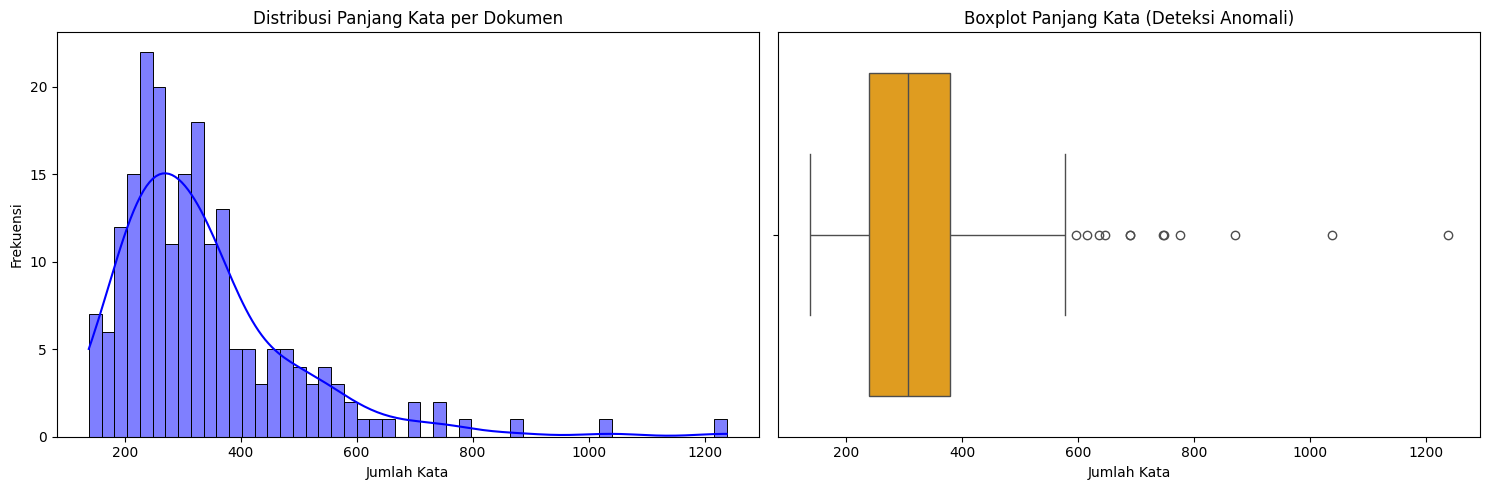

=== Statistik Deskriptif Panjang Kata ===


count     200.000000
mean      337.535000
std       155.955601
min       138.000000
25%       239.000000
50%       306.000000
75%       378.500000
max      1238.000000
Name: jumlah_kata, dtype: float64

In [59]:
print("Menganalisis panjang kata untuk mendeteksi anomali...")
visualisasi_panjang_kata(df_all, 'teks')

Membuat WordCloud...


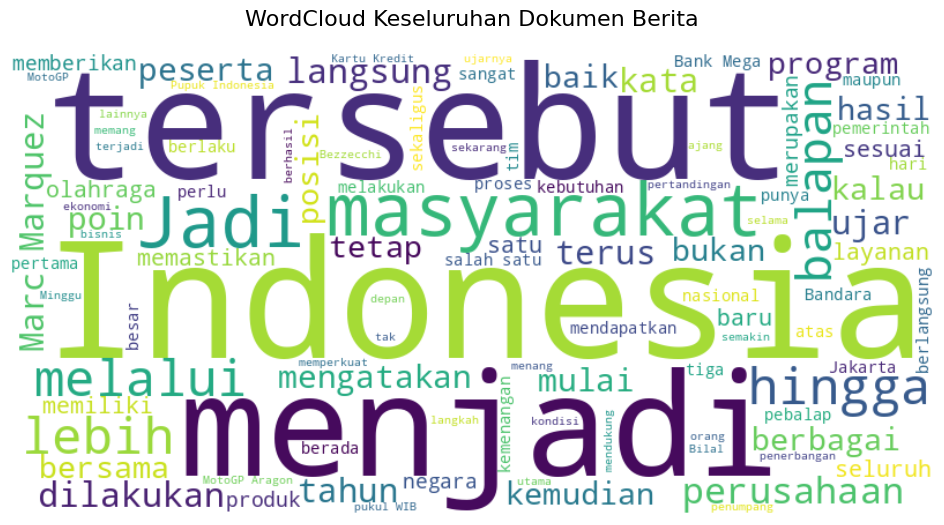

In [60]:
print("Membuat WordCloud...")
visualisasi_wordcloud(df_all['teks'])

In [61]:
hasil = cari_kata("saham")
display(hasil.head())

Ditemukan 8 dokumen yang mengandung kata 'saham'.


,kategori,teks
106,finance,Lembaga Penjamin Simpanan (LPS) memiliki dua f...
109,finance,Direktur Jenderal Stabilitas dan Pengembangan ...
146,finance,"Founder & Chairman CT Corp, Chairul Tanjung me..."
148,finance,Pasangan selebriti yang juga pendiri RANS Ente...
193,finance,PT Bank Tabungan Negara (Persero) Tbk (BTN) me...


## Data Preprocessing

In [62]:
def preprocess_modular(teks, hapus_angka=True, hapus_stopword=True, pakai_stemming=True):
    # 1. Case Folding & Hapus Tanda Baca
    teks = str(teks).lower()
    teks = re.sub(r'[^\w\s]', ' ', teks)
    
    # 2. Opsional: Hapus Angka
    if hapus_angka:
        teks = re.sub(r'\d+', '', teks)
        
    # 3. Tokenisasi
    tokens = teks.split()
    
    # 4. Opsional: Hapus Stopword
    if hapus_stopword:
        tokens = [w for w in tokens if w not in daftar_stopword]
        
    # 5. Opsional: Stemming
    if pakai_stemming:
        teks_gabung = " ".join(tokens)
        teks_stem = stemmer.stem(teks_gabung)
        tokens = teks_stem.split()
        
    # Return list of tokens (Format ideal untuk Gensim Word2Vec)
    return tokens

In [63]:
def latih_skipgram(list_of_tokens, ukuran_vektor=50, ukuran_window=2):
    """Melatih model Word2Vec Skip-gram dari kolom token dataframe."""
    model = Word2Vec(
        sentences=list_of_tokens,
        vector_size=ukuran_vektor,
        window=ukuran_window,
        sg=1,          # sg=1 mengaktifkan Skip-gram
        min_count=1,   # Pastikan semua kata masuk vocabulary
        workers=4,     # Mempercepat komputasi
        seed=42
    )
    return model

def get_vektor_rata_rata(tokens, model):
    """Merata-ratakan vektor setiap kata menjadi 1 vektor dokumen untuk klasifikasi ML."""
    vektor_kata = [model.wv[kata] for kata in tokens if kata in model.wv]
    
    if not vektor_kata:
        # Jika dokumen kosong (semua kata terhapus stopword), kembalikan array 0
        return np.zeros(model.vector_size)
        
    return np.mean(vektor_kata, axis=0)

In [64]:
daftar_stopword = set(StopWordRemoverFactory().get_stop_words())
stemmer = StemmerFactory().create_stemmer()

tqdm.pandas()

In [80]:
# Preprocessing Penuh (Hapus Angka, Stopword, Stemming)
print("1. Memulai Preprocessing Skenario 1 (Ini akan memakan waktu karena Stemming)...")
df_all['token_skenario_1'] = df_all['teks'].progress_apply(
    lambda x: preprocess_modular(x, hapus_angka=True, hapus_stopword=True, pakai_stemming=True)
)

1. Memulai Preprocessing Skenario 1 (Ini akan memakan waktu karena Stemming)...


100%|██████████| 200/200 [00:00<00:00, 1105.08it/s]


In [81]:
print("\n2. Melatih Model Skip-gram...")
# Gensim memiliki sistem log tersendiri untuk menampilkan progress pelatihan
# Kita aktifkan logger-nya sejenak ke level INFO
logging.basicConfig(format='%(asctime)s : %(message)s', level=logging.INFO)

model_skenario_1 = latih_skipgram(df_all['token_skenario_1'], ukuran_vektor=50, ukuran_window=3)

# Kembalikan logger ke WARNING agar output tidak kotor setelah selesai
logging.getLogger().setLevel(logging.WARNING)
print("Pelatihan Skip-gram Selesai!")


print("\n3. Membuat Vektor Rata-rata Dokumen (Mean Pooling)...")
fitur_X = df_all['token_skenario_1'].progress_apply(
    lambda x: get_vektor_rata_rata(x, model_skenario_1)
)

# Konversi ke DataFrame
df_skenario_1_X = pd.DataFrame(fitur_X.tolist())
df_skenario_1_y = df_all['kategori']

print("\nSeluruh proses Skenario 1 selesai!")


2. Melatih Model Skip-gram...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Pelatihan Skip-gram Selesai!

3. Membuat Vektor Rata-rata Dokumen (Mean Pooling)...


100%|██████████| 200/200 [00:00<00:00, 1079.51it/s]


Seluruh proses Skenario 1 selesai!


In [82]:
# Skenario 2: Pertahankan Angka, Hapus Stopword, Stemming
print("2. Memulai Preprocessing Skenario 2...")
df_all['token_skenario_2'] = df_all['teks'].progress_apply(
    lambda x: preprocess_modular(x, hapus_angka=False, hapus_stopword=True, pakai_stemming=True)
)

2. Memulai Preprocessing Skenario 2...


100%|██████████| 200/200 [00:00<00:00, 1039.34it/s]


In [83]:
print("\n2. Melatih Model Skip-gram...")
# Gensim memiliki sistem log tersendiri untuk menampilkan progress pelatihan
# Kita aktifkan logger-nya sejenak ke level INFO
logging.basicConfig(format='%(asctime)s : %(message)s', level=logging.INFO)

model_skenario_1 = latih_skipgram(df_all['token_skenario_2'], ukuran_vektor=50, ukuran_window=3)

# Kembalikan logger ke WARNING agar output tidak kotor setelah selesai
logging.getLogger().setLevel(logging.WARNING)
print("Pelatihan Skip-gram Selesai!")


print("\n3. Membuat Vektor Rata-rata Dokumen (Mean Pooling)...")
fitur_X = df_all['token_skenario_2'].progress_apply(
    lambda x: get_vektor_rata_rata(x, model_skenario_1)
)

# Konversi ke DataFrame
df_skenario_2_X = pd.DataFrame(fitur_X.tolist())
df_skenario_2_y = df_all['kategori']

print("\nSeluruh proses Skenario 2 selesai!")


2. Melatih Model Skip-gram...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Pelatihan Skip-gram Selesai!

3. Membuat Vektor Rata-rata Dokumen (Mean Pooling)...


100%|██████████| 200/200 [00:00<00:00, 1051.57it/s]


Seluruh proses Skenario 2 selesai!


## Modeling & Evaluasi

### Skenario 1

Melakukan Split antara data Train & Test Skenario 1

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    df_skenario_1_X, df_skenario_1_y, 
    test_size=0.2, 
    random_state=42, 
    stratify=df_skenario_1_y
)

Membuat Model Skenario 1

In [85]:
model_nb_skenario1 = GaussianNB()

# 3. Melatih Model dengan Data Latih
model_nb_skenario1.fit(X_train, y_train)

# 4. Memprediksi Data Uji
y_pred = model_nb_skenario1.predict(X_test)

Evaluasi Skenario 1

=== HASIL EVALUASI NAIVE BAYES (SKENARIO 1) ===
Akurasi Model : 82.50%

Laporan Klasifikasi Detail:
              precision    recall  f1-score   support

     finance       0.76      0.95      0.84        20
       sport       0.93      0.70      0.80        20

    accuracy                           0.82        40
   macro avg       0.85      0.82      0.82        40
weighted avg       0.85      0.82      0.82        40



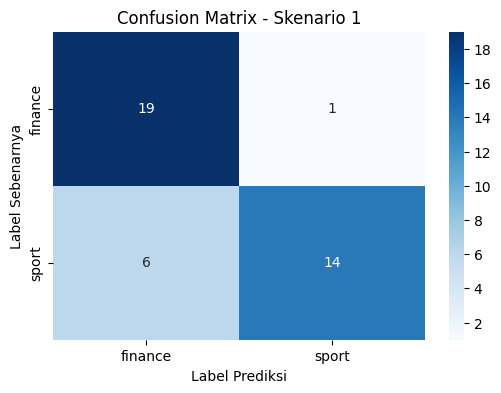

In [86]:
print("=== HASIL EVALUASI NAIVE BAYES (SKENARIO 1) ===")
print(f"Akurasi Model : {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Laporan Klasifikasi Detail:")
print(classification_report(y_test, y_pred))

# 6. Visualisasi Confusion Matrix (Opsional, sangat bagus untuk laporan)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model_nb_skenario1.classes_, 
            yticklabels=model_nb_skenario1.classes_)
plt.title('Confusion Matrix - Skenario 1')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Label Prediksi')
plt.show()

### Skenario 2

Melakukan Split antara data Train & Test Skenario 2

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    df_skenario_2_X, df_skenario_2_y, 
    test_size=0.2, 
    random_state=42, 
    stratify=df_skenario_2_y
)

Membuat Model Skenario 1

In [88]:
model_nb_skenario1 = GaussianNB()

# 3. Melatih Model dengan Data Latih
model_nb_skenario1.fit(X_train, y_train)

# 4. Memprediksi Data Uji
y_pred = model_nb_skenario1.predict(X_test)

Evaluasi Skenario 1

=== HASIL EVALUASI NAIVE BAYES (SKENARIO 1) ===
Akurasi Model : 77.50%

Laporan Klasifikasi Detail:
              precision    recall  f1-score   support

     finance       0.69      1.00      0.82        20
       sport       1.00      0.55      0.71        20

    accuracy                           0.78        40
   macro avg       0.84      0.78      0.76        40
weighted avg       0.84      0.78      0.76        40



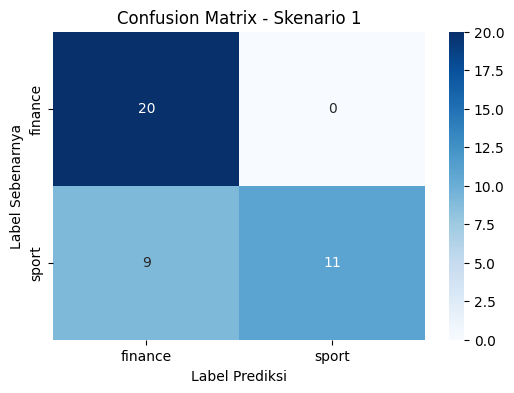

In [89]:
print("=== HASIL EVALUASI NAIVE BAYES (SKENARIO 1) ===")
print(f"Akurasi Model : {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Laporan Klasifikasi Detail:")
print(classification_report(y_test, y_pred))

# 6. Visualisasi Confusion Matrix (Opsional, sangat bagus untuk laporan)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model_nb_skenario1.classes_, 
            yticklabels=model_nb_skenario1.classes_)
plt.title('Confusion Matrix - Skenario 1')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Label Prediksi')
plt.show()